In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris_data = load_iris()

In [2]:
# Convert to DataFrame for easier handling
iris_df = pd.DataFrame(
    data = iris_data.data,
    columns = iris_data.feature_names
)
iris_df['species'] = iris_data.target

# Map numeric target to species name
iris_df['species'] = iris_df['species'].map(
    {i: name for i, name in enumerate(iris_data.target_names)}
)

In [3]:
# ---------------- Explore Structure ----------------
print("\n--- Dataset Info ---\n")
print(iris_df.info())

print("\n--- First 5 Rows ---\n")
print(iris_df.head())

print("\n--- Dataset Shape ---\n")
print(iris_df.shape)

print("\n--- Summary Statistics ---\n")
print(iris_df.describe())



--- Dataset Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

--- First 5 Rows ---

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4     

In [4]:
# ---------------- Check Missing Values ----------------
print("\n--- Missing Values ---\n")
print(iris_df.isnull().sum())

# If missing values existed, handle them (mean imputation example)
if iris_df.isnull().values.any():
    iris_df.fillna(iris_df.mean(numeric_only=True), inplace=True)
    print("\nMissing values were filled with column means.\n")


--- Missing Values ---

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


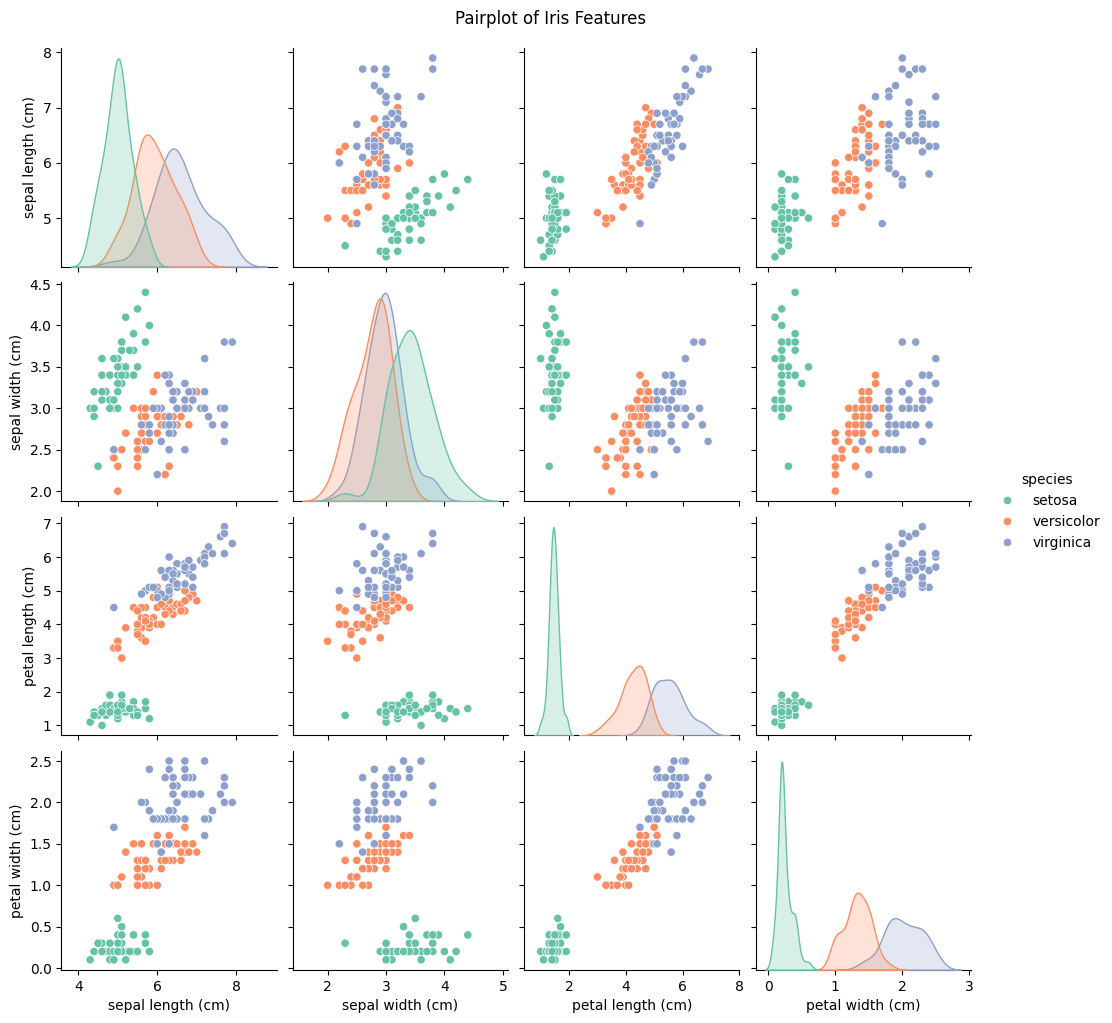

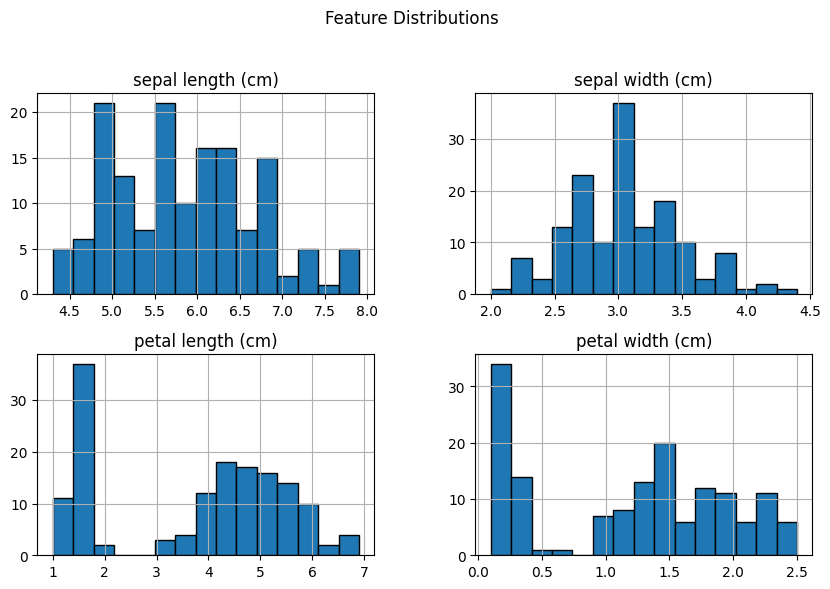

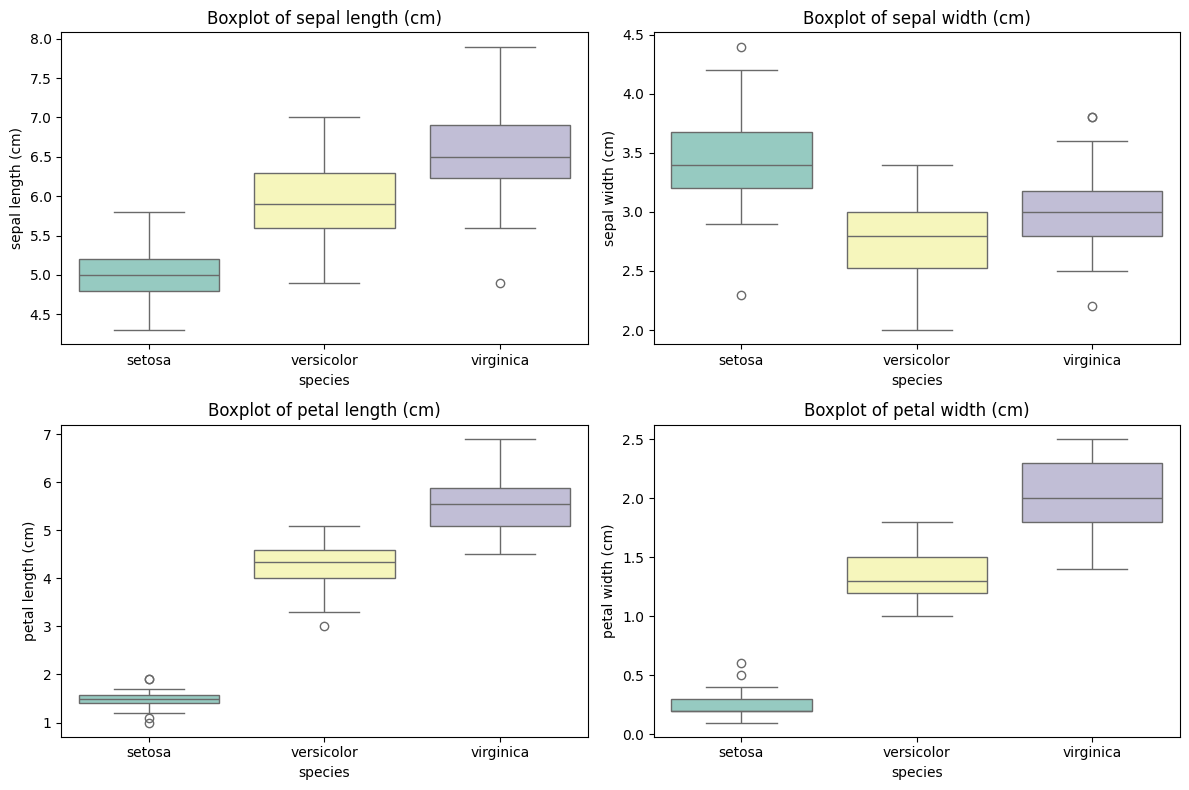

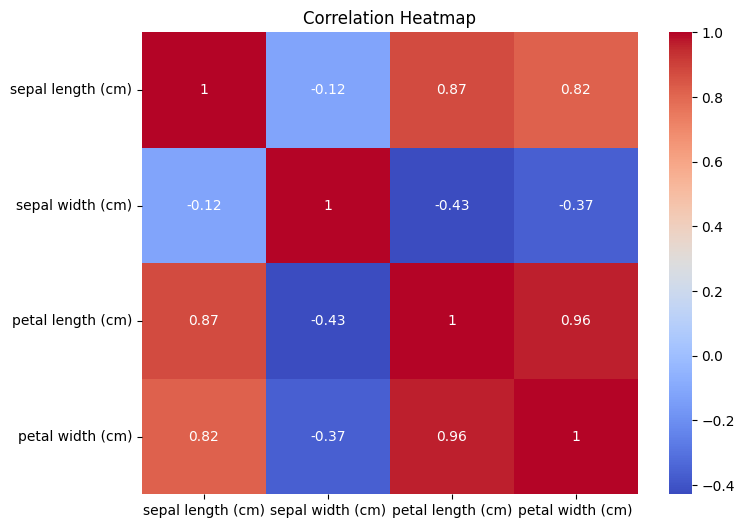

In [5]:
# ---------------- Visualizations ----------------

# Pairplot: feature relationships colored by species
sns.pairplot(iris_df, hue="species", diag_kind="kde", palette="Set2")
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Distribution plots for each feature
iris_df.drop("species", axis=1).hist(figsize=(10, 6), bins=15, edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

# Boxplots grouped by species
plt.figure(figsize=(12, 8))
for idx, column in enumerate(iris_data.feature_names, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(data=iris_df, x="species", y=column, hue="species", palette="Set3", legend=False)
    plt.title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

# Heatmap of feature correlations
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df.drop("species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()